# Multi-Gaussian Expansion Lens Light Profiles in `dolphin`

This notebook demonstrates how to use lenstronomy's **MGE_SET** and **MGE_SET_ELLIPSE** (Multi-Gaussian Expansion) light profiles as lens light models in `dolphin`.

A Multi-Gaussian Expansion (MGE) is a sum of Gaussian components with logarithmically-spaced widths. It is a flexible light profile that performs well in modeling typical lensing galaxies, e.g., [He et al. 2024](https://ui.adsabs.harvard.edu/abs/2024MNRAS.532.2441H/abstract).

`dolphin` supports the following `lenstronomy` MGE light profiles:
- **MGE_SET**: Circular Gaussians. Parameters: `amp` (array), `sigma_min`, `sigma_width`, `center_x`, `center_y`
- **MGE_SET_ELLIPSE**: Elliptical Gaussians. The parameters above, plus `e1`, `e2` ellipticity parameters.

The `n_comp` parameter controls how many Gaussian components are used. The individual `amp` values are linear parameters solved automatically by `lenstronomy`'s linear optimizer.

### Imports

In [1]:
import matplotlib.pyplot as plt

from dolphin.processor import Processor
from dolphin.analysis.output import Output

### Config file format

To use MGE_SET or MGE_SET_ELLIPSE as a lens light profile in `dolphin`, set the model in your config YAML:

```yaml
model:
  lens_light: ['MGE_SET_ELLIPSE']

lens_light_option:
  mge_config:
    0:
      n_comp: 20  # number of Gaussian components
```

The `n_comp` parameter is specified per profile index in `mge_config`. If not specified, the default is 20.

### Available configuration options

| Option | Location | Description |
|--------|----------|-------------|
| `n_comp` | `lens_light_option.mge_config.{index}.n_comp` | Number of Gaussian components (default: 20) |
| Fix parameters | `lens_light_option.fix.{index}` | Fix `sigma_min`, `sigma_width`, `e1`, `e2`, etc. |
| Gaussian priors | `lens_light_option.gaussian_prior.{index}` | Apply Gaussian priors on parameters |
| Initial guesses | `guess_params.lens_light.{index}` | Override initial parameter values |

### Example: Fixing sigma_min

```yaml
lens_light_option:
  mge_config:
    0:
      n_comp: 15
  fix:
    0:
      sigma_min: 0.02  # fix the minimum Gaussian width
```

### Run a model with MGE_SET_ELLIPSE

Now let's run an actual lens model using MGE_SET_ELLIPSE as the lens light profile. We use the same data as `lens_system2` from the "Basic example" notebook, with the config at `io_directory_example/settings/lens_system_mge_config.yaml`.

In [2]:
processor = Processor("../io_directory_example/")
processor.swim(
    lens_name="lens_system_mge",
    model_id="example_mge",
    log=False,
    thread_count=32,
    recipe_name="galaxy-galaxy",
)

Optimizing model for lens_system_mge with recipe: galaxy-galaxy.


Computing the PSO ...


100%|██████████| 50/50 [00:17<00:00,  2.78it/s]

Max iteration reached! Stopping.
-0.4778706800031999 reduced X^2 of best position
-91.99010590061597 log likelihood
385 effective number of data points
[{'theta_E': 1.0, 'gamma': 2.0, 'e1': 0.0, 'e2': 0.0, 'center_x': np.float64(0.02255494715657937), 'center_y': np.float64(-0.04556191009125215)}, {'gamma_ext': 0.05, 'psi_ext': 0.0, 'ra_0': 0, 'dec_0': 0}] lens result
[{'amp': 1, 'n_max': 4, 'beta': 0.1, 'center_x': 0.0, 'center_y': 0.0}] source result
[{'amp': 1, 'sigma_min': np.float64(0.01520324736409476), 'sigma_width': np.float64(1.145881282184597), 'e1': np.float64(-0.14380216747681318), 'e2': np.float64(-0.008713481171178775), 'center_x': np.float64(0.02255494715657937), 'center_y': np.float64(-0.04556191009125215)}] lens light result
[] point source result
[] tracer source result
{} special param result
17.977214813232422 time used for  PSO


Computing the PSO ...


...

100%|██████████| 50/50 [00:50<00:00,  1.01s/it]

Max iteration reached! Stopping.
-1.1038931292126117 reduced X^2 of best position
-7925.400721181945 log likelihood
14359 effective number of data points
[{'theta_E': np.float64(1.2287805890549937), 'gamma': 2.0, 'e1': np.float64(0.03696329774772326), 'e2': np.float64(0.022452007670368482), 'center_x': np.float64(0.023702051546841914), 'center_y': np.float64(-0.04293484224965742)}, {'gamma_ext': 0.05, 'psi_ext': 0.0, 'ra_0': 0, 'dec_0': 0}] lens result
[{'amp': 1, 'n_max': 4, 'beta': np.float64(0.10284931081034561), 'center_x': np.float64(0.041693194941725964), 'center_y': np.float64(-0.27636402658027176)}] source result
[{'amp': 1, 'sigma_min': np.float64(0.05677437661042522), 'sigma_width': np.float64(0.8954284769138552), 'e1': np.float64(-0.1368242373146555), 'e2': np.float64(-0.00016687756137245802), 'center_x': np.float64(0.023702051546841914), 'center_y': np.float64(-0.04293484224965742)}] lens light result
[] point source result
[] tracer source result
{} special param result
50

Computing the PSO ...


100%|██████████| 50/50 [00:50<00:00,  1.00s/it]

Max iteration reached! Stopping.
-1.0937633242046974 reduced X^2 of best position
-7849.392496155011 log likelihood
14353 effective number of data points
[{'theta_E': np.float64(1.2315940738228057), 'gamma': 2.0, 'e1': np.float64(0.034900853001488596), 'e2': np.float64(0.021928755885770007), 'center_x': np.float64(0.026327271235674212), 'center_y': np.float64(-0.04671687322034086)}, {'gamma_ext': 0.05, 'psi_ext': 0.0, 'ra_0': 0, 'dec_0': 0}] lens result
[{'amp': 1, 'n_max': 4, 'beta': np.float64(0.10263697414399856), 'center_x': np.float64(0.04224679658801939), 'center_y': np.float64(-0.27734802781366996)}] source result
[{'amp': 1, 'sigma_min': np.float64(0.0607168767445353), 'sigma_width': np.float64(0.995852785420682), 'e1': np.float64(-0.08953172603457651), 'e2': np.float64(-0.0003243398835837512), 'center_x': np.float64(0.026327271235674212), 'center_y': np.float64(-0.04671687322034086)}] lens light result
[] point source result
[] tracer source result
{} special param result
50.1

### Inspect the output

-1.0901934632411008 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.090210323614881


/data/bwedig/.conda/envs/dolphin/lib/python3.12/site-packages/lenstronomy/Plots/model_band_plot.py:161: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),


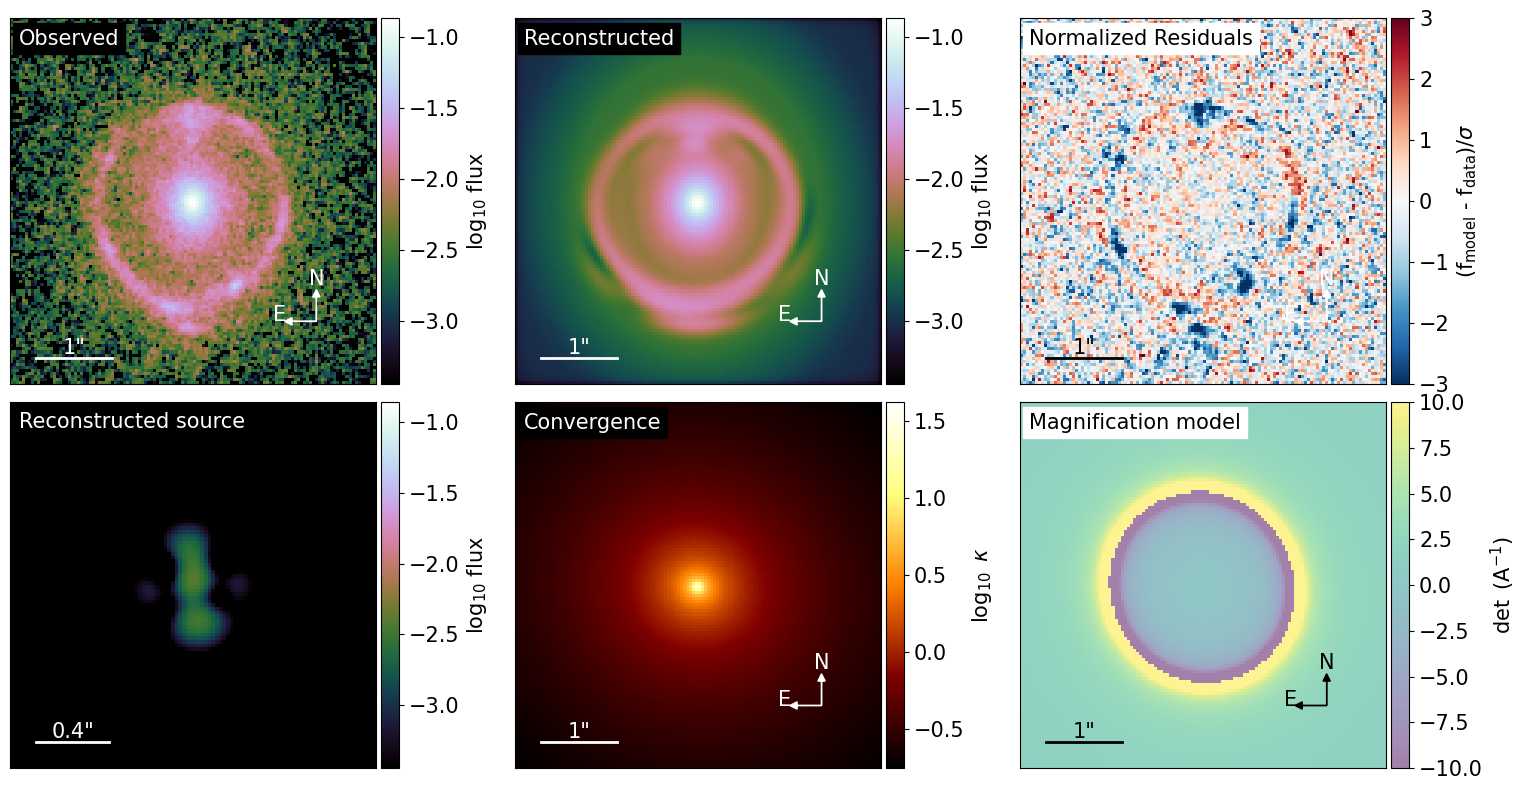

In [3]:
output = Output("../io_directory_example/")
fig = output.plot_model_overview(lens_name="lens_system_mge", model_id="example_mge")

In [4]:
output.load_output(lens_name="lens_system_mge", model_id="example_mge")

print("Lens light result:")
for key, val in output.kwargs_result["kwargs_lens_light"][0].items():
    print(f"  {key}: {val}")

print("\nFull kwargs_result:")
output.kwargs_result

Lens light result:
  amp: 1
  sigma_min: 0.0607168767445353
  sigma_width: 0.995852785420682
  e1: -0.08953172603457651
  e2: -0.0003243398835837512
  center_x: 0.026327271235674212
  center_y: -0.04671687322034086

Full kwargs_result:


{'kwargs_lens': [{'theta_E': 1.2315940738228057,
   'gamma': 2.0,
   'e1': 0.034900853001488596,
   'e2': 0.021928755885770007,
   'center_x': 0.026327271235674212,
   'center_y': -0.04671687322034086},
  {'gamma_ext': 0.05, 'psi_ext': 0.0, 'ra_0': 0, 'dec_0': 0}],
 'kwargs_source': [{'amp': 1,
   'n_max': 4,
   'beta': 0.10263697414399856,
   'center_x': 0.04224679658801939,
   'center_y': -0.27734802781366996}],
 'kwargs_lens_light': [{'amp': 1,
   'sigma_min': 0.0607168767445353,
   'sigma_width': 0.995852785420682,
   'e1': -0.08953172603457651,
   'e2': -0.0003243398835837512,
   'center_x': 0.026327271235674212,
   'center_y': -0.04671687322034086}],
 'kwargs_ps': [],
 'kwargs_special': {},
 'kwargs_extinction': [],
 'kwargs_tracer_source': []}

### Compare Sersic vs. MGE lens light models

Let's look at a side-by-side comparison of modeling results from `lens_system2` (SERSIC_ELLIPSE) and `lens_system_mge` (MGE_SET_ELLIPSE) on the same data.

-1.080620130383151 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.0806201303831522
-1.0901934632411008 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.090210323614881


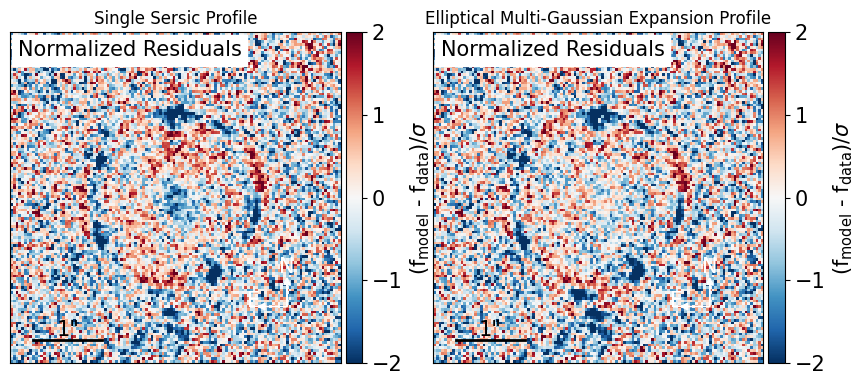

In [6]:
model_plot_sersic, v_max_sersic = output.get_model_plot_instance(
    "lens_system2", model_id="example"
)
model_plot_mge, v_max_mge = output.get_model_plot_instance(
    "lens_system_mge", model_id="example_mge"
)

_, ax = plt.subplots(1, 2, figsize=(10, 5))
model_plot_sersic.normalized_residual_plot(ax=ax[0], cmap="RdBu_r", v_max=2, v_min=-2)
ax[0].set_title("Single Sersic Profile")
model_plot_mge.normalized_residual_plot(ax=ax[1], cmap="RdBu_r", v_max=2, v_min=-2)
ax[1].set_title("Elliptical Multi-Gaussian Expansion Profile")
plt.show()